<div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 40px; margin-top: 0;">
    <div style="flex: 0 0 auto; margin-left: 0; margin-bottom: 0; margin-top: 0;">
        <img src="./pics/UCSD Logo.png" alt="UCSD Logo" style="width: 179px; margin-bottom: 0px; margin-top: 20px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/LANL-logo.png" alt="LANL Logo" style="width: 200px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/prowess.png" alt="Prowess Logo" style="width: 200px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/wildfire.png" alt="WildFire Logo" width="100"/>
    </div>
</div>

<h1 style="text-align: center; font-size: 48px; margin-top: 0;">Fire-Ready Forests Data Challenge</h1>

# Sprint 2 - Tasks 1-2

**Team Name:** Heatmappers 

**Members:**

- Ansh Bhatnagar
- Ishayu Ghosh
- Jeronimo Adames-Baena
- Jason Qin

Use this notebook to report your solutions for tasks 1-2 of Sprint 2. Add code and markdown cells as needed to report your solutions.

### Task 1

Select an ALS scan from a site other than Independence Lake. Generate the corresponding Canopy Height Model (CHM) and treelist for the selected scan. Ensure that the output files include your `team-name` at the end of each filename.

To correctly associate each LiDAR file with its respective location, use the Plot Identification file inside the ALS dataset. This file provides information about each plot, linking scans file names to specific areas.

In [11]:
# First, we import all the libraries
import pc_rasterize as pcr
import glob
import numpy as np
import requests
import pandas as pd
from dask.distributed import Client, LocalCluster, Lock
import rasterio
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max
from pyproj import Transformer

url = "https://wifire-data.sdsc.edu/nc/s/nnSMqWfZAN6Cz6m/download?path=%2Fnew_data%2FRaw%20ALS%20and%20Detected%20Trees%2FALS%20data&files=USGS_LPC_CA_SouthernSierra_2020_B20_w0298n4108.laz&downloadStartSecret=aik5h9wexsu"
local_als = "./USGS_LPC_CA_CALAVERASTUOLUMNE_2011_000386.laz"



response = requests.get(url, stream=True)
with open(local_als, "wb") as file:
    for chunk in response.iter_content(chunk_size=8192):
        file.write(chunk)

In [12]:
# Extracts the basic metadata from that .laz file
# Important as it told us the CRS value for this file which was needed for the block below
print(f"Downloaded: {local_als}")
pcr.get_file_quickinfo('./USGS_LPC_CA_CALAVERASTUOLUMNE_2011_000386.laz')

Downloaded: ./USGS_LPC_CA_CALAVERASTUOLUMNE_2011_000386.laz


LidarInfo(n_points=38817490, dims=('X', 'Y', 'Z', 'Intensity', 'ReturnNumber', 'NumberOfReturns', 'ScanDirectionFlag', 'EdgeOfFlightLine', 'Classification', 'Synthetic', 'KeyPoint', 'Withheld', 'Overlap', 'ScanAngleRank', 'UserData', 'PointSourceId', 'GpsTime', 'ScanChannel', 'Amplitude', 'Reflectance', 'Deviation'), crs=CRS.from_wkt('COMPD_CS["NAD83(2011) / UTM zone 11N + NAVD88 height - Geoid18 (m)",PROJCS["NAD83(2011) / UTM zone 11N",GEOGCS["NAD83(2011)",DATUM["NAD83_National_Spatial_Reference_System_2011",SPHEROID["GRS 1980",6378137,298.257222101]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","6318"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["meter",1],AXIS["X",EAST],AXIS["Y",NORTH],AUTHORITY["EPSG","6340"]],VERT_CS["NAVD88 height - Geoid18 (m)

In [13]:
als = glob.glob('./USGS_LPC_CA_NoCAL_3DEP_Supp_Funding_2018_D18_w2251n2042.laz')
#Changed the CRS value to correspond to the new ALS file
geobox = pcr.build_geobox(als, resolution=1., crs="6340")
chm = pcr.rasterize(
    als,
    geobox,
    cell_func="max",
    # Set custom dask chunk-size
    chunksize=(1000, 1000),
    nodata=np.nan,
    pdal_filters=[
    {
        "type":"filters.range",
        "limits":"Classification[1:5]" # Keep points classified as 'vegetation' - https://desktop.arcgis.com/en/arcmap/latest/manage-data/las-dataset/lidar-point-classification.htm
    },
    {
      "type":"filters.outlier" # Remove outliers
    },
    {
        "type":"filters.hag_nn" # Compute Height Above Ground (HAG) using the nearest-neighbor method. 
    },
    {
        "type":"filters.ferry",
        "dimensions":"HeightAboveGround=>Z" # Move the computed HAG values into the `Z` coordinate for easier processing.  
    },
    {
      "type":"filters.outlier" # Remove outliers again
    },
    {
        "type": "filters.expression",
        "expression": "Z < 75" # Filters out points higher than 75m (unrealistic height in our context) 
    }
    ]
)

chm

<xarray.DataArray 'rasterized_pc' (band: 1, y: 1185, x: 1210)> Size: 6MB
dask.array<broadcast_to, shape=(1, 1185, 1210), dtype=float32, chunksize=(1, 1000, 1000), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 9kB 4.285e+06 4.285e+06 ... 4.283e+06 4.283e+06
  * x            (x) float64 10kB 2.741e+04 2.741e+04 ... 2.862e+04 2.862e+04
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:  nan

In [14]:
with LocalCluster(n_workers=8, threads_per_worker=1, memory_limit='24GB') as cluster, Client(cluster) as client:
    chm_squeezed = chm.squeeze()  # We remove an extra dimension with no data
    chm_squeezed.rio.to_raster("./chm-new.tiff", tiled=True, lock=Lock("rio"))
print("Successfuly computed the CHM!")

Successfuly computed the CHM!


### Task 2

Generate two visualizations:

- A Canopy Height Model (CHM) visualization.
- A distribution plot of tree heights extracted from your treelist.

Finally, compare your treelist to the sample treelist derived from the Independence Lake ALS scan. Provide a brief analysis highlighting similarities, differences, and any notable trends in tree height distribution across sites.

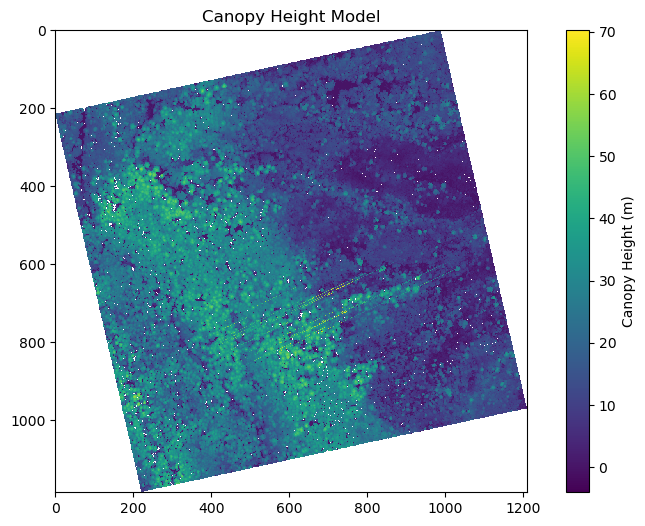

In [15]:
# Task 2 - Your code here
chm_path = "./chm-new.tiff"
with rasterio.open(chm_path) as src:
    chm = src.read(1)  
    transform = src.transform  # Affine transform for georeferencing
    crs = src.crs  # Get raster Coordinate Reference System

# Let's quickly visualize our raster
plt.figure(figsize=(10, 6))
plt.imshow(chm, cmap="viridis", interpolation="nearest")
plt.colorbar(label="Canopy Height (m)")
plt.title("Canopy Height Model")
plt.show()

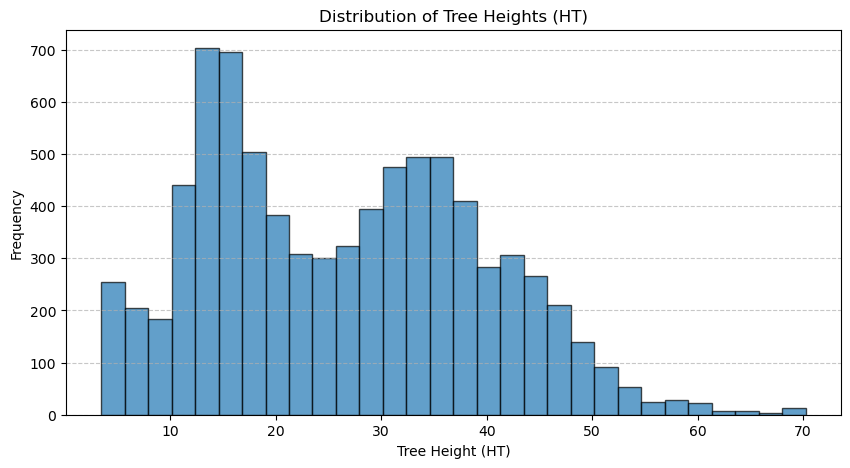

In [16]:
# Normalize CHM 
chm_norm = (chm - np.nanmin(chm)) / (np.nanmax(chm) - np.nanmin(chm))

# Locate tree tops using local maxima filtering
tree_tops = peak_local_max(chm_norm, min_distance=3, threshold_abs=0.1, exclude_border=False)

# Convert pixel coordinates to geospatial coordinates and extract heights
tree_points = []
for row, col in tree_tops:
    x, y = transform * (int(col), int(row))  
    height = chm[row, col] 
    tree_points.append((height, y, x)) 

df = pd.DataFrame(tree_points, columns=["HT", "y", "x"])

# Let´s look at the df
df.head()


# Let's take a look at the distribution of tree heights
plt.figure(figsize=(10, 5))
plt.hist(df["HT"], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Tree Height (HT)")
plt.ylabel("Frequency")
plt.title("Distribution of Tree Heights (HT)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [17]:
# Convert to Lat/Lon system
if crs and crs.to_epsg() != 4326:
    transformer = Transformer.from_crs(crs.to_epsg(), "EPSG:4326", always_xy=True)
    df["x"], df["y"] = transformer.transform(df["x"].values, df["y"].values) 

# Save CSV
df.to_csv("./ttops-new.csv", index=False)
print(f"TreeTops saved to ./data/ttops.csv with {len(df)} points")

TreeTops saved to ./data/ttops.csv with 8026 points
